In [2]:
import numpy as np
import lightkurve as lk 
import matplotlib.pyplot as plt 
from astroquery.jplhorizons import Horizons
import pandas as pd
from astropy.time import Time

In [47]:
# From Animation70
def getData(ra:float, dec:float, sectorno:int):
    location = str(ra) + ", " + str(dec)
    search_result = lk.search_tesscut(location, sector=sectorno)
    tpf = search_result.download(cutout_size=20)
    return tpf

In [4]:
# time conversions

def BTJDtoUTC(btjd):
    bjd = btjd + 2457000.0  # BTJD is BJD - 2457000.0
    time_bjd = Time(bjd, format='jd', scale='tdb')
    time_utc = time_bjd.utc.iso
    return time_utc

def cadenceToUTC(total_cadence, btjd_min, btjd_max): #ig in theory you could just do this based on tess cadence
    step_days = (btjd_max - btjd_min) / total_cadence
    step_minutes = step_days * 1440
    return step_minutes
    
print(BTJDtoUTC(3208) + " " + BTJDtoUTC(3234))
cadenceToUTC(10715, 3208, 3234)

2023-09-20 11:58:50.818 2023-10-16 11:58:50.818


3.4941670555296316

In [5]:
# Get the location of Neptune during a certain time (Neptune Horizons id is 899)

eph_cols = ['targetname', 'datetime_str', 'datetime_jd', 'RA', 'DEC']

start_70 = str(BTJDtoUTC(3208))
stop_70 = str(BTJDtoUTC(3234))
cadence_70 = '3m'

sector_70 = Horizons(id=899, epochs={'start':start_70, 'stop':stop_70, 'step':cadence_70})
ephemeris_70 = sector_70.ephemerides()
df_70 = ephemeris_70.to_pandas()[eph_cols]

#column titles
header_70 = ephemeris_70.colnames

print(df_70)

          targetname              datetime_str   datetime_jd         RA  \
0      Neptune (899)  2023-Sep-20 11:58:50.818  2.460208e+06  356.75201   
1      Neptune (899)  2023-Sep-20 12:01:50.818  2.460208e+06  356.75196   
2      Neptune (899)  2023-Sep-20 12:04:50.818  2.460208e+06  356.75191   
3      Neptune (899)  2023-Sep-20 12:07:50.818  2.460208e+06  356.75186   
4      Neptune (899)  2023-Sep-20 12:10:50.818  2.460208e+06  356.75180   
...              ...                       ...           ...        ...   
12476  Neptune (899)  2023-Oct-16 11:46:50.818  2.460234e+06  356.12313   
12477  Neptune (899)  2023-Oct-16 11:49:50.818  2.460234e+06  356.12308   
12478  Neptune (899)  2023-Oct-16 11:52:50.818  2.460234e+06  356.12303   
12479  Neptune (899)  2023-Oct-16 11:55:50.818  2.460234e+06  356.12299   
12480  Neptune (899)  2023-Oct-16 11:58:50.818  2.460234e+06  356.12294   

           DEC  
0     -2.79780  
1     -2.79783  
2     -2.79785  
3     -2.79787  
4     -2.79790

In [52]:
#Making a circular aperture functions

def circularAperture(dimensions, center, radius):
    """
    Create a boolean array with specified dimensions, setting a circular area to True.
    
    Parameters:
    dimensions (tuple): The dimensions of the array (rows, cols).
    center (tuple): The center of the circle (x, y).
    radius (int): The radius of the circle.
    
    Returns:
    np.ndarray: A boolean array with True in the specified circle and False elsewhere.
    """
    # Initialize the array with False
    array = np.zeros(dimensions, dtype=bool)
    
    cx, cy = center
    for x in range(dimensions[1]):
        for y in range(dimensions[0]):
            if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                array[y, x] = True
    
    return array

In [48]:
tpf1 = getData(df_70.loc[0, 'RA'], df_70.loc[0, 'DEC'], 70)

<Axes: title={'center': 'Target ID: 356.75201, -2.7978, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

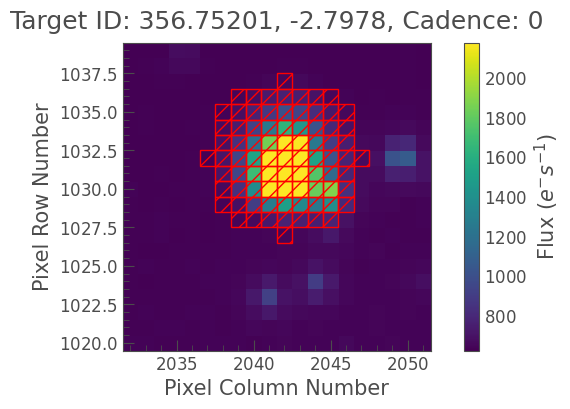

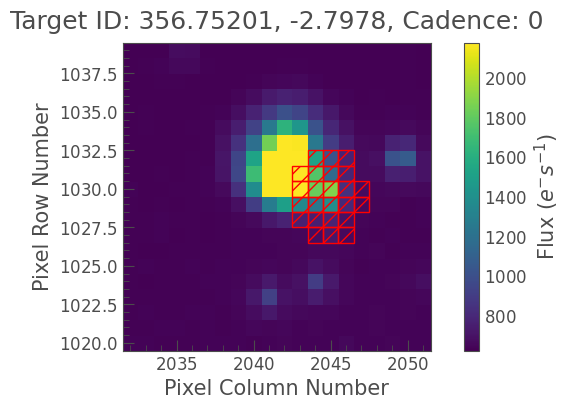

In [70]:
zoomed_aperture = circularAperture((20,20), (10, 12), 5)
threshold_aperture = tpf1.create_threshold_mask(threshold=7, reference_pixel=(10,10))
tpf1.plot(aperture_mask = zoomed_aperture)
tpf1.plot(aperture_mask = threshold_aperture)

In [81]:
cadence = 0
flux1 = tpf1.flux[cadence]
max_flux_position = np.unravel_index(np.nanargmax(flux1), flux1.shape)

print(f"Maximum flux value: {flux1[max_flux_position]}")
print(f"Pixel with the most flux at cadence {cadence} is at position (y, x): {max_flux_position}")

Maximum flux value: 17119.443359375 electron / s
Pixel with the most flux at cadence 0 is at position (y, x): (11, 10)


<Axes: title={'center': 'Target ID: 356.75201, -2.7978, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

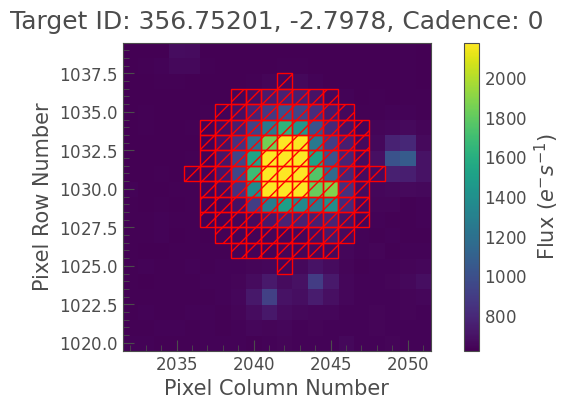

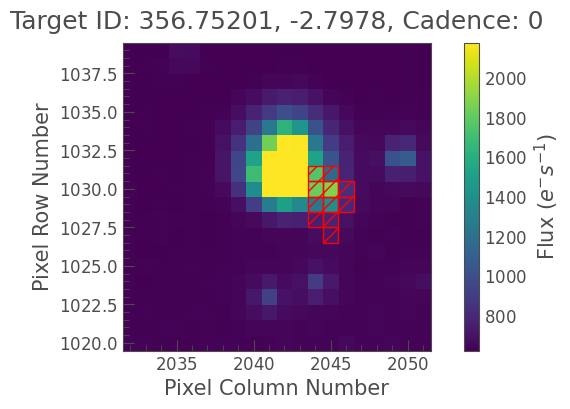

In [89]:
aperture = circularAperture((20,20), (10, 11), 6)
tpf1.plot(aperture_mask = aperture)

